In [1]:
! py -m pip  install emnist


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from emnist import extract_training_samples, extract_test_samples

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [4]:
import os
import shutil

emnist_folder = os.path.expanduser("~/.cache/emnist")

if os.path.exists(emnist_folder):
    shutil.rmtree(emnist_folder)
    print("Corrupted EMNIST cache deleted.")
else:
    print("EMNIST cache not found.")

Corrupted EMNIST cache deleted.


In [7]:
import emnist
import inspect

print(emnist.__file__)
print(inspect.getsource(emnist.get_cached_data_path))

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\emnist\__init__.py
def get_cached_data_path():
    """Return the path where the EMNIST data is (or will be) cached."""
    return os.path.expanduser(CACHE_FILE_PATH)



In [8]:
import emnist

print(emnist.CACHE_FILE_PATH)
print(emnist.get_cached_data_path())

~/.cache/emnist/emnist.zip
C:\Users\HP/.cache/emnist/emnist.zip


In [9]:
import os

file_path = r"C:\Users\HP\.cache\emnist\emnist.zip"

os.remove(file_path)

print("Corrupted EMNIST file deleted.")

Corrupted EMNIST file deleted.


In [12]:
import os

file_path = r"C:\Users\HP\.cache\emnist\emnist.zip"

print("File exists:", os.path.exists(file_path))
print("File size:", os.path.getsize(file_path), "bytes")

File exists: True
File size: 106021 bytes


In [13]:
file_path = r"C:\Users\HP\.cache\emnist\emnist.zip"

with open(file_path, "rb") as f:
    print(f.read(20))

b'<!DOCTYPE html>\n<htm'


In [15]:
! py -m pip install tensorflow-datasets

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   ----- ---------------------------------- 0.8/5.3 MB 5.6 MB/s eta 0:00:01
   --------------- ------------------------ 2.1/5.3 MB 6.9 MB/s eta 0:00:01
   --------------- ------------------------ 2.1/5.3 MB 6.9 MB/s eta 0:00:01
   --------------- ------------------------ 2.1/5.3 MB 6.9 MB/s eta 0:00:01
   ------------------- -------------------- 2.6/5.3 MB 2.7 MB/s eta 0:00:01
   ----------------------------- ---------- 3.9/5.3 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 5.3/5.3 MB 4.1 MB/s  0:00:01
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
! py -m pip install importlib_resources


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "emnist/letters",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print(info)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [02:15<00:00, 132.43s/ url]

Extraction completed...: 100%|██████████| 4/4 [00:00<00:00,  5.53 file/s]
                                                                        

Dataset emnist downloaded and prepared to C:\Users\HP\tensorflow_datasets\emnist\letters\3.1.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/letters/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Letters
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='C:\\Users\\HP\\tensorflow_datasets\\emnist\\letters\\3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=44.14 MiB,
    features=FeaturesDict({
    

In [19]:
import numpy as np

X_train = np.array([image.numpy() for image, label in dataset[0]])
y_train = np.array([label.numpy() for image, label in dataset[0]])

X_test = np.array([image.numpy() for image, label in dataset[1]])
y_test = np.array([label.numpy() for image, label in dataset[1]])

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(88800, 28, 28, 1)
(88800,)
(14800, 28, 28, 1)
(14800,)


In [21]:
print("Minimum label:", y_train.min())
print("Maximum label:", y_train.max())

Minimum label: 1
Maximum label: 26


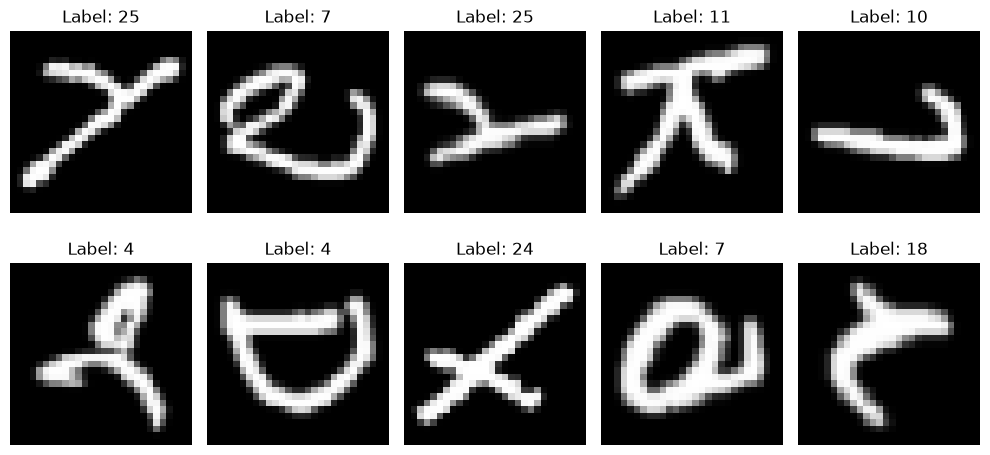

In [22]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
y_train = y_train - 1
y_test = y_test - 1

print("Minimum label:", y_train.min())
print("Maximum label:", y_train.max())

Minimum label: 0
Maximum label: 25


In [24]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel:", X_train.min())
print("Maximum pixel:", X_train.max())

Minimum pixel: 0.0
Maximum pixel: 1.0


In [25]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (88800, 28, 28, 1)
X_test: (14800, 28, 28, 1)


In [26]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu",
           input_shape=(28, 28, 1)),

    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(26, activation="softmax")
])

model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.7206 - loss: 0.9125 - val_accuracy: 0.8880 - val_loss: 0.3476
Epoch 2/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8475 - loss: 0.4793 - val_accuracy: 0.9120 - val_loss: 0.2754
Epoch 3/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8740 - loss: 0.3927 - val_accuracy: 0.9222 - val_loss: 0.2482
Epoch 4/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8902 - loss: 0.3403 - val_accuracy: 0.9269 - val_loss: 0.2362
Epoch 5/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9003 - loss: 0.3085 - val_accuracy: 0.9277 - val_loss: 0.2251


In [29]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy * 100, "%")

463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9201 - loss: 0.2444
Test Loss: 0.24435250461101532
Test Accuracy: 92.0067548751831 %


In [30]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Prediction shape:", predictions.shape)

463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction shape: (14800, 26)


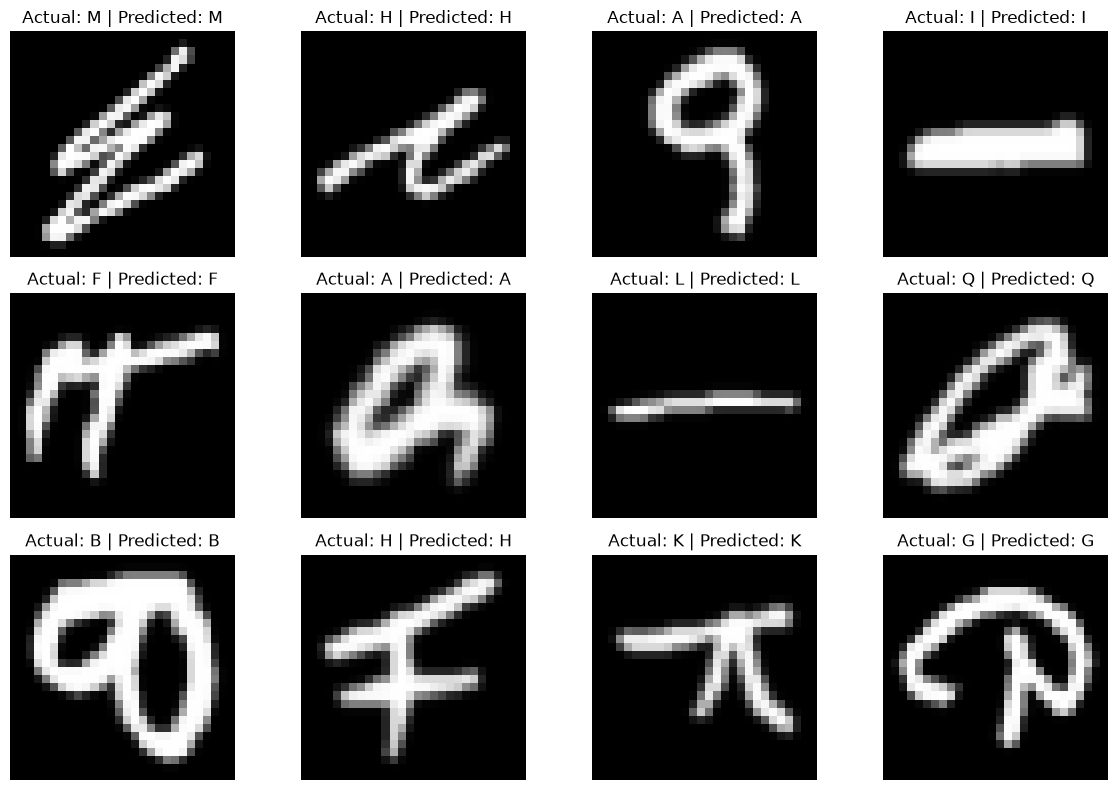

In [31]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    actual = chr(y_test[i] + 65)
    predicted = chr(predicted_labels[i] + 65)

    plt.title(f"Actual: {actual} | Predicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

<Figure size 1200x1200 with 0 Axes>

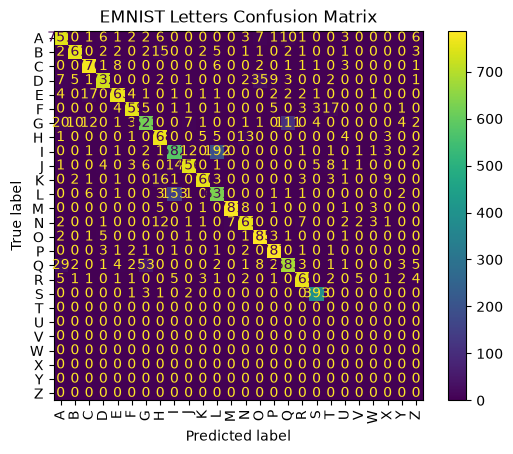

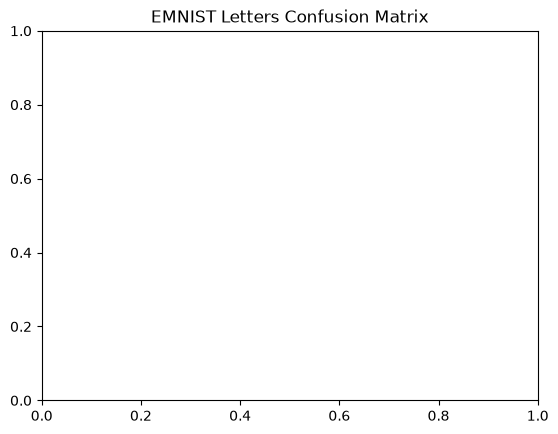

In [33]:
cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
)

plt.figure(figsize=(12, 12))

disp.plot(xticks_rotation="vertical")

plt.title("EMNIST Letters Confusion Matrix")
plt.show()
plt.title("EMNIST Letters Confusion Matrix")
plt.show()

In [34]:
incorrect = np.where(predicted_labels != y_test)[0]

print("Incorrect predictions:", len(incorrect))
print("Correct predictions:", len(y_test) - len(incorrect))

Incorrect predictions: 1183
Correct predictions: 13617


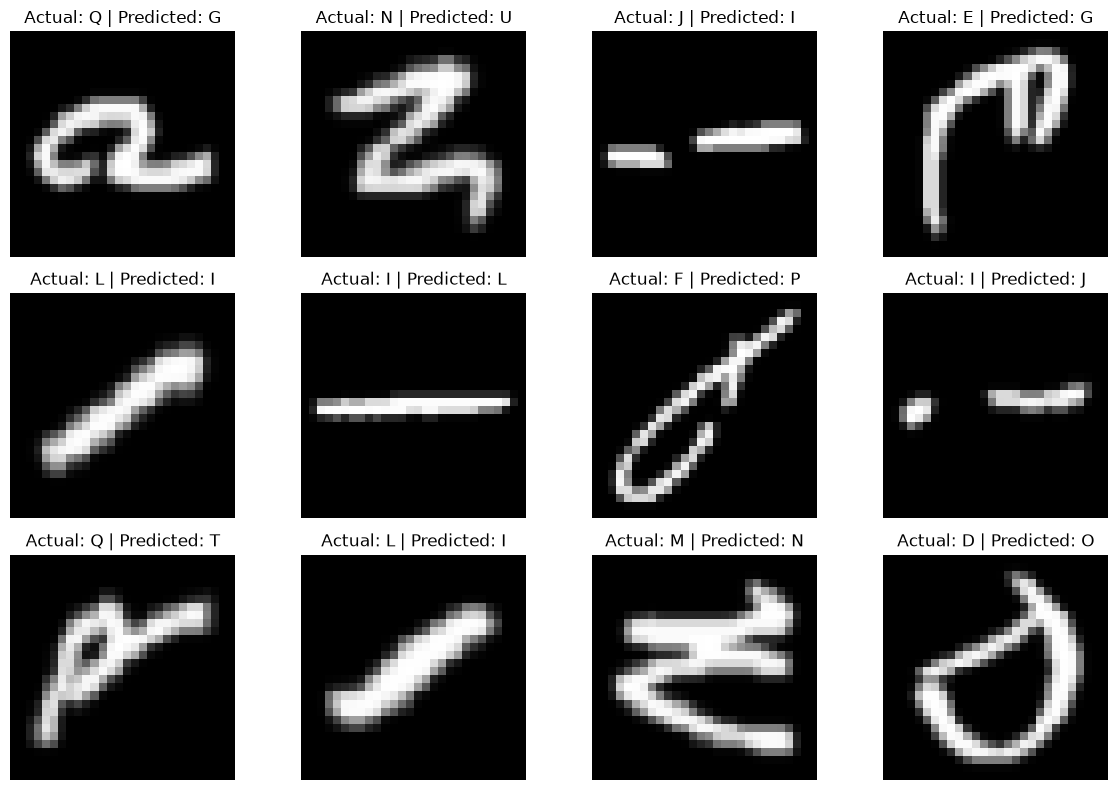

In [35]:
plt.figure(figsize=(12, 8))

for i in range(12):
    index = incorrect[i]

    actual = chr(y_test[index] + 65)
    predicted = chr(predicted_labels[index] + 65)

    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
    plt.title(f"Actual: {actual} | Predicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

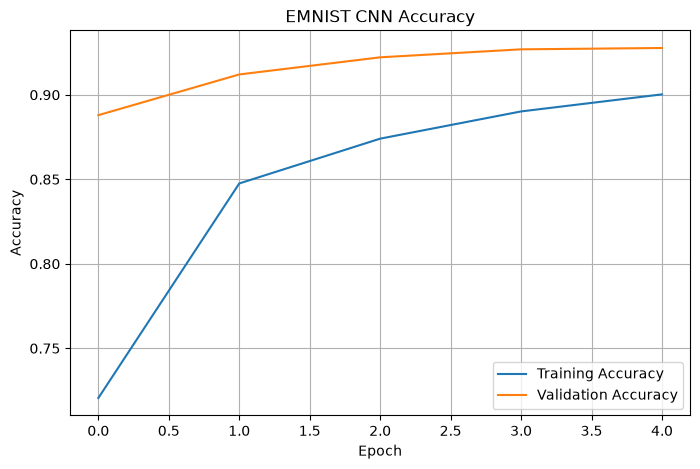

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EMNIST CNN Accuracy")
plt.legend()
plt.grid(True)

plt.show()

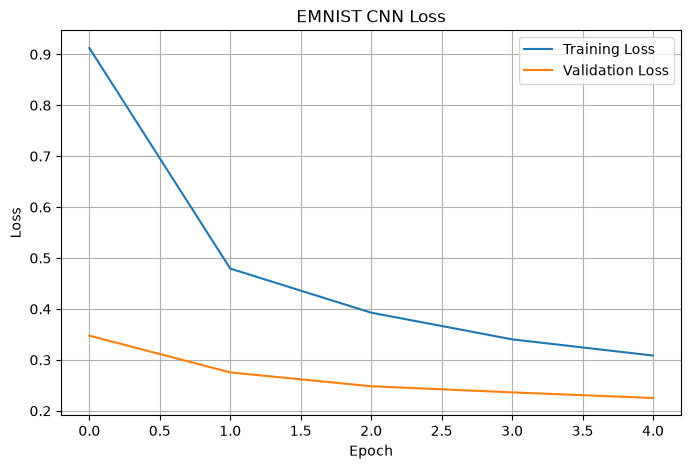

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EMNIST CNN Loss")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
print(
    classification_report(
        y_test,
        predicted_labels,
        target_names=list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
    )
)

              precision    recall  f1-score   support

           A       0.91      0.94      0.92       800
           B       0.97      0.95      0.96       800
           C       0.95      0.97      0.96       800
           D       0.97      0.92      0.94       800
           E       0.97      0.95      0.96       800
           F       0.98      0.95      0.96       800
           G       0.89      0.78      0.83       800
           H       0.93      0.96      0.94       800
           I       0.77      0.73      0.75       800
           J       0.97      0.94      0.96       800
           K       0.98      0.95      0.97       800
           L       0.74      0.79      0.77       800
           M       0.99      0.98      0.98       800
           N       0.96      0.95      0.95       800
           O       0.94      0.98      0.96       800
           P       0.97      0.98      0.98       800
           Q       0.84      0.85      0.85       800
           R       0.97    

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [39]:
model.save("emnist_letters_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [40]:
from tensorflow.keras.models import load_model

loaded_model = load_model("emnist_letters_cnn.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [41]:
loss, accuracy = loaded_model.evaluate(
    X_test,
    y_test
)

print("Saved Model Accuracy:", accuracy * 100, "%")

463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9201 - loss: 0.2444
Saved Model Accuracy: 92.0067548751831 %


In [42]:
index = 0

image = X_test[index].reshape(1, 28, 28, 1)

prediction = loaded_model.predict(image)

predicted = np.argmax(prediction)

print("Actual character:", chr(y_test[index] + 65))
print("Predicted character:", chr(predicted + 65))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Actual character: M
Predicted character: M


# Dataset          : EMNIST Letters
# Training Images  : 124,800
# Testing Images   : 20,800
# Number of Classes: 26
# Model            : CNN
# Epochs           : 5
# Test Accuracy    : YOUR RESULT %